# Exact metrics for asynchronous Boolean networks

**This tutorial is written for BoolForge's `asynchronous` development
branch. The metrics it covers are not yet available on the `main` branch
or the PyPI release.**

In this tutorial, we take a closer look at
`get_terminal_sccs_and_robustness_asynchronous_exact`, the method
introduced in Tutorial 8 for computing exact asynchronous robustness
measures. On this branch, the method is extended with several additional
metrics, each of which is also available as its own, standalone method.

## What you will learn
In this tutorial you will:

- compute all exact asynchronous metrics at once,
- compute the same metrics individually, using the underlying methods,
- identify which of these metrics are new to the `asynchronous` branch, and
- interpret expected absorption times, the asynchronous analogue of height.

## Installation

The `asynchronous` branch is not on PyPI, so it must be installed directly
from GitHub. If `boolforge` is already installed, uninstall it first so
that the branch version is not shadowed by an existing installation:

```bash
pip uninstall boolforge
pip install "git+https://github.com/ckadelka/BoolForge.git@asynchronous"
```

## Setup

In [1]:
import boolforge as bf
import numpy as np
import matplotlib.pyplot as plt

We reuse the small Boolean network from Tutorial 8.

In [2]:
string = """
x = y
y = x OR z
z = y
"""

bn = bf.BooleanNetwork.from_string(string, separator="=")

print("Variables:", bn.variables)
print("Number of nodes:", bn.N)

Variables: ['x' 'y' 'z']
Number of nodes: 3


## Computing everything at once

`compute_absorption_times` is new to this branch and is off by default,
since it requires solving an additional linear system on top of the rest
of the computation. With it enabled, the dictionary also contains expected
absorption times.

In [3]:
results = bn.get_terminal_sccs_and_robustness_asynchronous_exact(
    compute_absorption_times=True
)

for key in results.keys():
    print(key)

TerminalSCCs
NumberOfTerminalSCCs
LengthOfTerminalSCCs
TrapSpaceDimensions
BasinSizes
AbsorptionProbabilities
Coherence
BasinCoherences
TerminalSCCCoherencesUniform
TerminalSCCCoherencesStationary
BasinEntropy
StateEntropies
MeanStateEntropyPerBasin
ExpectedAbsorptionTimesAny
ExpectedAbsorptionTimesSpecific
NetworkDivergence
LocalDivergences


## Computing individual metrics

Each of these entries, apart from the coherence measures, can also be
obtained from its own method. Results are cached on the network object, so
calling several of them in sequence does not repeatedly rebuild the state
transition graph (STG) or re-solve the absorption system.

The `asynchronous` branch adds four new metrics that are not part of the
`main` branch, marked *(new)* below: basin sizes as a standalone method
(previously only computed internally), entropy, divergence, and expected
absorption times.

| Method | Dictionary entries |
|---|---|
| `get_asynchronous_transition_matrix()` | the STG itself |
| `get_terminal_sccs_asynchronous_exact()` | `TerminalSCCs`, `NumberOfTerminalSCCs`, `LengthOfTerminalSCCs` |
| `get_minimal_trap_spaces_asynchronous_exact()` | `TrapSpaceDimensions` |
| `get_absorption_probabilities_exact()` | `AbsorptionProbabilities` |
| `get_basin_sizes_asynchronous_exact()` *(new)* | `BasinSizes` |
| `compute_entropy()` *(new)* | `BasinEntropy`, `StateEntropies`, `MeanStateEntropyPerBasin` |
| `get_divergence()` *(new)* | `NetworkDivergence`, `LocalDivergences` |
| `get_expected_absorption_times_exact()` *(new)* | `ExpectedAbsorptionTimesAny`, `ExpectedAbsorptionTimesSpecific` |

### Terminal SCCs and trap spaces

The minimal trap space of a terminal SCC marks nodes fixed within it by
their value (0 or 1) and nodes that vary by -1. The number of varying nodes
is the trap space dimension.

In [4]:
terminal_sccs = bn.get_terminal_sccs_asynchronous_exact()
trap_spaces = bn.get_minimal_trap_spaces_asynchronous_exact()

print("Terminal SCCs:", terminal_sccs)
print("Minimal trap spaces:\n", trap_spaces)
print("Number of frozen nodes:", bn.get_number_frozen_nodes_asynchronous_exact())

Terminal SCCs: [[0], [7]]
Minimal trap spaces:
 [[0 0 0]
 [1 1 1]]
Number of frozen nodes: 0


### Absorption probabilities and basin sizes

Because asynchronous dynamics are stochastic, a state does not belong to a
single basin. Instead, each state $x$ has a probability of eventually being
absorbed into each terminal SCC $a$. The basin size of $a$ is the mean of
these probabilities over all $2^N$ states, so basin sizes sum to 1.

In [5]:
absorption_probs = bn.get_absorption_probabilities_exact()
basin_sizes = bn.get_basin_sizes_asynchronous_exact()

print("Absorption probabilities:\n", absorption_probs.round(3))
print("Basin sizes:", basin_sizes)

Absorption probabilities:
 [[1.    0.   ]
 [0.5   0.5  ]
 [0.333 0.667]
 [0.    1.   ]
 [0.5   0.5  ]
 [0.333 0.667]
 [0.    1.   ]
 [0.    1.   ]]
Basin sizes: [0.33333334 0.6666667 ]


### Entropy and divergence *(new in this branch)*

The Shannon entropy of a state's absorption probabilities measures how
undetermined its fate is: 0 if the state reaches a single terminal SCC with
certainty, $\ln(k)$ if it is equally likely to reach each of $k$ terminal
SCCs. `compute_entropy` also returns the entropy of the basin-size
distribution and the mean state entropy, overall and within each basin.

The local divergence at a state is the mean Jensen-Shannon divergence
between its absorption probabilities and those of its one-bit neighbors,
i.e., how much a single perturbation changes the likely outcome. The
network divergence is its mean over all states.

In [6]:
entropies = bn.compute_entropy()
network_divergence, local_divergences = bn.get_divergence()

print("State entropies:", entropies["state_entropies"].round(3))
print("Basin entropy:", round(float(entropies["basin_entropy"]), 3))
print("Network divergence:", round(float(network_divergence), 3))

State entropies: [-0.     0.693  0.637 -0.     0.693  0.637 -0.    -0.   ]
Basin entropy: 0.637
Network divergence: 0.134


## Expected absorption times *(new in this branch)*

Under synchronous updating, the *height* of a state (also called its
transient length) is the number of update steps needed to reach an
attractor, computed by `get_transient_lengths_exact()`; attractor states
themselves have height 0. Under asynchronous updating, the order in which
nodes are updated is random, so the number of steps to reach a terminal SCC
is a random variable rather than a fixed number. Its expectation, the
*expected absorption time*, plays the same role as height: it is 0 on the
terminal SCCs and increases with a state's distance from them.

`get_expected_absorption_times_exact()` returns two arrays:

- `ExpectedAbsorptionTimesAny`, of shape $(2^N,)$: the expected number of
  steps until absorption into *any* terminal SCC.
- `ExpectedAbsorptionTimesSpecific`, of shape $(2^N, \text{number of
  terminal SCCs})$: the expected number of steps until absorption,
  conditioned on absorption into a *specific* terminal SCC. Entries are
  `NaN` where that terminal SCC is unreachable from that state.

In [7]:
times_any, times_specific = bn.get_expected_absorption_times_exact()

print("Expected absorption time into any terminal SCC:", times_any)
print("Expected absorption time, conditioned on each terminal SCC:\n", times_specific)

Expected absorption time into any terminal SCC: [0.        1.5       1.6666667 1.        1.5       2.        1.
 0.       ]
Expected absorption time, conditioned on each terminal SCC:
 [[ 0. nan]
 [ 1.  2.]
 [ 1.  2.]
 [nan  1.]
 [ 1.  2.]
 [ 2.  2.]
 [nan  1.]
 [nan  0.]]


The two arrays are linked by the law of total expectation: the
unconditional expected time is the average of the conditional times,
weighted by the absorption probabilities.
$$
\mathbb{E}[T_x] = \sum_a P(x \to a)\, \mathbb{E}[T_x \mid x \to a].
$$

In [8]:
reconstructed = np.nansum(absorption_probs * times_specific, axis=1)
print("Law of total expectation holds:", np.allclose(reconstructed, times_any, atol=1e-5))

Law of total expectation holds: True


### Height and absorption time across random networks

Because attractors and update steps differ between the two schemes, height
and expected absorption time need not agree state by state. Comparing their
means across an ensemble of random networks shows how the two notions of
"distance to an attractor" relate on average.

Pearson correlation: 0.407


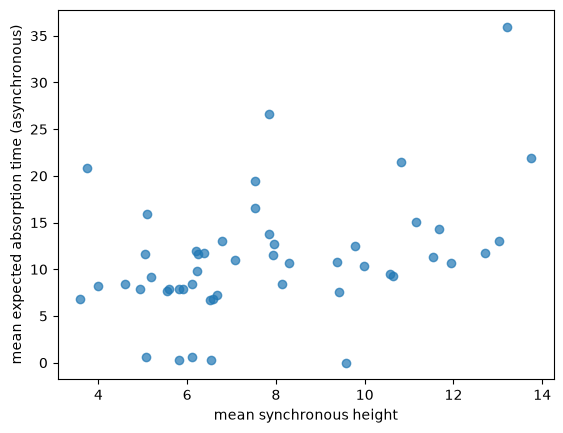

In [9]:
rng = np.random.default_rng(0)
N, n, n_networks = 10, 2, 50

mean_heights, mean_absorption_times = [], []
for _ in range(n_networks):
    random_bn = bf.random_network(N, n, rng=rng)
    mean_heights.append(random_bn.get_transient_lengths_exact().mean())
    t_any, _ = random_bn.get_expected_absorption_times_exact()
    mean_absorption_times.append(t_any.mean())

plt.scatter(mean_heights, mean_absorption_times, alpha=0.7)
plt.xlabel("mean synchronous height")
plt.ylabel("mean expected absorption time (asynchronous)")

print("Pearson correlation:", round(np.corrcoef(mean_heights, mean_absorption_times)[0, 1], 3))

## Summary

In this tutorial you learned how to:

- install BoolForge's `asynchronous` development branch,
- compute all exact asynchronous metrics with a single call to
  `get_terminal_sccs_and_robustness_asynchronous_exact`,
- compute the same metrics individually, including entropy, divergence,
  and expected absorption times, all new to this branch, and
- interpret expected absorption time as the asynchronous analogue of
  height.